In [8]:
# ============================================================
# CELL 0 – RUN THIS FIRST IN EVERY NOTEBOOK (do not modify)
# ============================================================
import os, sys
from google.colab import drive
import torch

# Step 1: Mount Google Drive
drive.mount('/content/drive', force_remount=False)
DRIVE_ROOT = "/content/drive/MyDrive/HateSpeech_NLP"

# Step 2: Clone or pull the Git repository
# CHANGE THIS TO YOUR ACTUAL REPO URL
REPO_URL  = "https://github.com/thong7d/hate-speech-detection.git"
REPO_NAME = "hate-speech-detection"
REPO_PATH = f"/content/{REPO_NAME}"

if not os.path.exists(REPO_PATH):
    os.system(f"git clone {REPO_URL} {REPO_PATH}")
else:
    os.system(f"cd {REPO_PATH} && git pull origin main")

# Step 3: Install the package in editable mode
os.system(f"pip install -q -e {REPO_PATH}")

# Step 4: Add src/ to Python path
if f"{REPO_PATH}/src" not in sys.path:
    sys.path.insert(0, f"{REPO_PATH}/src")

# Step 5: Install remaining dependencies
os.system(f"pip install -q -r {REPO_PATH}/requirements.txt")

print("✅ Environment ready. REPO_PATH:", REPO_PATH)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Environment ready. REPO_PATH: /content/hate-speech-detection


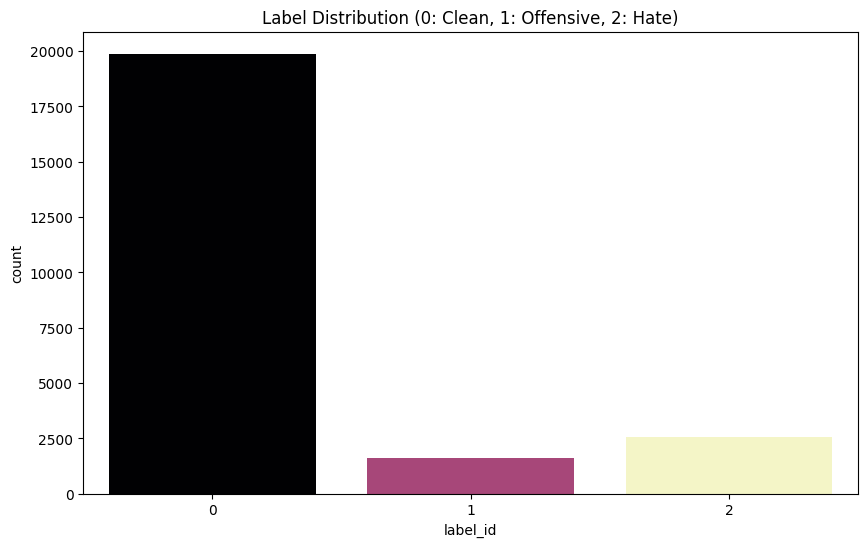

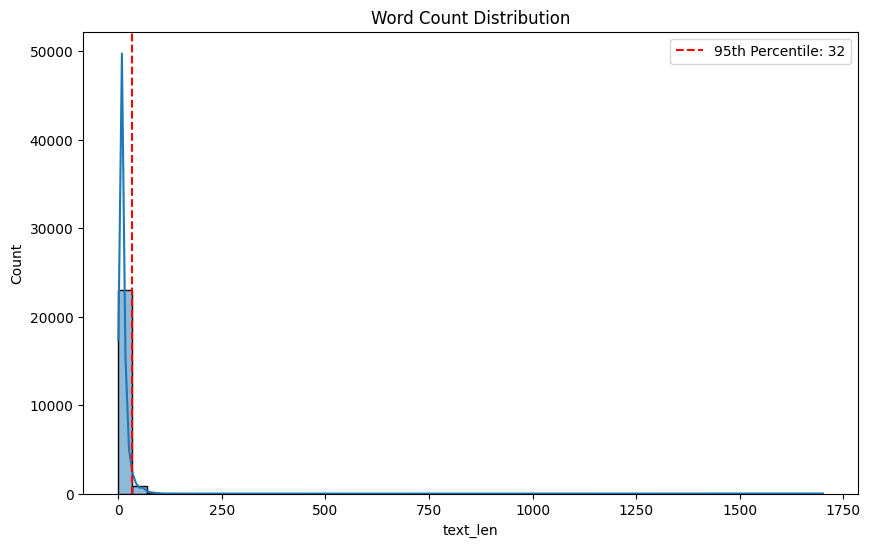

Decision: Recommended max_length is 32 words.


In [9]:
# ============================================================
# CELL 1 – LOAD DATA AND CONFIG
# ============================================================
import pandas as pd
import yaml
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load paths from config
with open(f"{REPO_PATH}/configs/paths.yaml", 'r') as f:
    paths = yaml.safe_load(f)

# Path setup (Lưu ý: Bạn cần đảm bảo paths.yaml trỏ đúng vào data/raw/vihsd/)
train_path = os.path.join(DRIVE_ROOT, "data/raw/vihsd/train.csv")
train_df = pd.read_csv(train_path)

# 1. Label Distribution
plt.figure(figsize=(10, 6))
sns.countplot(x='label_id', data=train_df, hue='label_id', palette='magma', legend=False)
plt.title('Label Distribution (0: Clean, 1: Offensive, 2: Hate)')
plt.savefig(f"{DRIVE_ROOT}/results/label_distribution.png")
plt.show()

# 2. Text Length Analysis (To decide max_length for Phase 5)
train_df['text_len'] = train_df['free_text'].fillna('').apply(lambda x: len(x.split()))
p95 = np.percentile(train_df['text_len'], 95)

plt.figure(figsize=(10, 6))
sns.histplot(train_df['text_len'], bins=50, kde=True)
plt.axvline(p95, color='r', linestyle='--', label=f'95th Percentile: {int(p95)}')
plt.title('Word Count Distribution')
plt.legend()
plt.savefig(f"{DRIVE_ROOT}/results/text_length_dist.png")
plt.show()

print(f"Decision: Recommended max_length is {int(p95)} words.")